In [49]:
'''
import numpy as np
import matplotlib.pyplot as plt
import random

from astropy.modeling.models import BlackBody
from astropy import units as u
from astropy.visualization import quantity_support

const = 1000

flam_sr_unit = u.erg / (u.cm**2 * u.s * u.AA * u.sr)
bb = BlackBody(temperature=2000 * u.K, scale= 1 * flam_sr_unit)

wav = np.arange(3000, 1e5+1) * u.AA
flux = 5*bb(wav)


noisy_flux = []
for i in range(len(flux)):
    n = random.gauss(mu=flux[i].value, sigma=5*np.sqrt(5*flux[i].value) + const)
    noisy_flux.append(n)

plt.figure(figsize=(18,6))
plt.step(wav,flux,alpha=.5,c='k')
plt.step(wav,noisy_flux,alpha=.5)
plt.xscale('log')
'''

"\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport random\n\nfrom astropy.modeling.models import BlackBody\nfrom astropy import units as u\nfrom astropy.visualization import quantity_support\n\nconst = 1000\n\nflam_sr_unit = u.erg / (u.cm**2 * u.s * u.AA * u.sr)\nbb = BlackBody(temperature=2000 * u.K, scale= 1 * flam_sr_unit)\n\nwav = np.arange(3000, 1e5+1) * u.AA\nflux = 5*bb(wav)\n\n\nnoisy_flux = []\nfor i in range(len(flux)):\n    n = random.gauss(mu=flux[i].value, sigma=5*np.sqrt(5*flux[i].value) + const)\n    noisy_flux.append(n)\n\nplt.figure(figsize=(18,6))\nplt.step(wav,flux,alpha=.5,c='k')\nplt.step(wav,noisy_flux,alpha=.5)\nplt.xscale('log')\n"

In [7]:
'''
import numpy as np
import matplotlib.pyplot as plt

from astropy.modeling.models import BlackBody, Gaussian1D
from astropy import units as u

const = 1000

flam_sr_unit = u.erg / (u.cm**2 * u.s * u.AA * u.sr)
bb = BlackBody(temperature=2000 * u.K, scale=1 * flam_sr_unit)

wav = np.arange(3000, 1e5 + 1) * u.AA

# 1. Base continuum
flux = 5 * bb(wav)

# 2. Define emission lines with higher relative peaks and narrower widths
# (Center Wavelength, Height relative to local continuum, Width in Å)
emission_lines = [
    (6563 * u.AA,  5.0,  50 * u.AA),   # H-alpha (6,563 Å): 200% continuum height, 50 Å width
    (18750 * u.AA, 1.5, 150 * u.AA),   # Pa-alpha (18,750 Å): 150% continuum height, 150 Å width
    (40510 * u.AA, 4, 300 * u.AA)    # Br-alpha (40,510 Å): 180% continuum height, 300 Å width
]

# 3. Add lines using local continuum scaling
for center, rel_height, width in emission_lines:
    continuum_at_line = 5 * bb(center)
    amplitude = rel_height * continuum_at_line
    
    g = Gaussian1D(amplitude=amplitude, mean=center, stddev=width)
    flux += g(wav)

# 4. Add noise
sigma = 5 * np.sqrt(5 * flux.value) + const
noisy_flux = np.random.normal(loc=flux.value, scale=sigma)

# Plotting
plt.figure(figsize=(18, 6))
plt.step(wav, flux, alpha=0.8, label='Blackbody + Peaked Emission Lines', color='blue')
plt.step(wav, noisy_flux, alpha=0.3, label='Noisy Spectrum', color='orange')
plt.xscale('log')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.legend()
plt.show()
'''

"\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nfrom astropy.modeling.models import BlackBody, Gaussian1D\nfrom astropy import units as u\n\nconst = 1000\n\nflam_sr_unit = u.erg / (u.cm**2 * u.s * u.AA * u.sr)\nbb = BlackBody(temperature=2000 * u.K, scale=1 * flam_sr_unit)\n\nwav = np.arange(3000, 1e5 + 1) * u.AA\n\n# 1. Base continuum\nflux = 5 * bb(wav)\n\n# 2. Define emission lines with higher relative peaks and narrower widths\n# (Center Wavelength, Height relative to local continuum, Width in Å)\nemission_lines = [\n    (6563 * u.AA,  5.0,  50 * u.AA),   # H-alpha (6,563 Å): 200% continuum height, 50 Å width\n    (18750 * u.AA, 1.5, 150 * u.AA),   # Pa-alpha (18,750 Å): 150% continuum height, 150 Å width\n    (40510 * u.AA, 4, 300 * u.AA)    # Br-alpha (40,510 Å): 180% continuum height, 300 Å width\n]\n\n# 3. Add lines using local continuum scaling\nfor center, rel_height, width in emission_lines:\n    continuum_at_line = 5 * bb(center)\n    amplitude = rel_height * cont

In [6]:
#TEST
'''
import numpy as np
import matplotlib.pyplot as plt

# Ensure variables are NumPy arrays (fixes the TypeError)
wav_val = np.asarray(wav.value if hasattr(wav, 'value') else wav)
#flux_val = np.asarray(flux.value if hasattr(flux, 'value') else flux)
noisy_flux_val = np.asarray(noisy_flux.value if hasattr(noisy_flux, 'value') else noisy_flux)

rmss = []
mean_sqrt_flux = []
mean_sqrt_noisy_flux = []
mean_fluxes = []
mean_noisy_fluxes = []

bin_size = 200  # You can now change this to any value

min_wav = np.min(wav_val)
max_wav = np.max(wav_val)
print(max_wav)

bin_edges = np.arange(min_wav, max_wav + bin_size, bin_size)
print(len(bin_edges)-1)
for i in range(len(bin_edges) - 1):
    low = bin_edges[i]
    high = bin_edges[i + 1]

    mask = (wav_val >= low) & (wav_val < high)

    # Require at least 2 points to compute difference between neighbors
    if np.sum(mask) < 2:
        continue

    wav_bin = wav_val[mask]
    #print(f'start:{wav_bin[0]}')
    #print(f'end: {wav_bin[-1]}')
    #flux_bin = flux_val[mask]
    #print(f'start:{flux_bin[0]}')
    #print(f'end: {flux_bin[-1]}')
    noisy_flux_bin = noisy_flux_val[mask]

    #mean_flux = np.mean(flux_bin)
    #mean_fluxes.append(mean_flux)

    mean_noisy_flux = np.mean(noisy_flux_bin)
    mean_noisy_fluxes.append(mean_noisy_flux)
    
    #mean_sqrt_flux.append(5*np.sqrt(5*mean_flux)+1000 if mean_flux >= 0 else np.nan)
    mean_sqrt_noisy_flux.append(5*np.sqrt(5*mean_noisy_flux)+1000 if mean_noisy_flux >= 0 else np.nan)

    left = noisy_flux_bin[1:]
    right = noisy_flux_bin[:-1]
    diff = (left - right) ** 2
    rms = np.sqrt(np.mean(diff))
    rmss.append(rms)

# make into numpy array
#mean_sqrt_flux = np.array(mean_sqrt_flux)
mean_sqrt_noisy_flux = np.array(mean_sqrt_noisy_flux)
rmss = np.array(rmss)

x = np.linspace(0, 5000, 10)
y = np.linspace(0, 5000, 10)

plt.figure(figsize=(5, 5))
plt.scatter(mean_noisy_fluxes, rmss, s=13,alpha=.7)
#plt.plot(x, y,c='k',alpha=.5)
plt.xlabel(r'flux in window')
plt.ylabel('RMS')
plt.show()
'''

"\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Ensure variables are NumPy arrays (fixes the TypeError)\nwav_val = np.asarray(wav.value if hasattr(wav, 'value') else wav)\n#flux_val = np.asarray(flux.value if hasattr(flux, 'value') else flux)\nnoisy_flux_val = np.asarray(noisy_flux.value if hasattr(noisy_flux, 'value') else noisy_flux)\n\nrmss = []\nmean_sqrt_flux = []\nmean_sqrt_noisy_flux = []\nmean_fluxes = []\nmean_noisy_fluxes = []\n\nbin_size = 200  # You can now change this to any value\n\nmin_wav = np.min(wav_val)\nmax_wav = np.max(wav_val)\nprint(max_wav)\n\nbin_edges = np.arange(min_wav, max_wav + bin_size, bin_size)\nprint(len(bin_edges)-1)\nfor i in range(len(bin_edges) - 1):\n    low = bin_edges[i]\n    high = bin_edges[i + 1]\n\n    mask = (wav_val >= low) & (wav_val < high)\n\n    # Require at least 2 points to compute difference between neighbors\n    if np.sum(mask) < 2:\n        continue\n\n    wav_bin = wav_val[mask]\n    #print(f'start:{wav_bin[0]}')\n  

In [5]:
import numpy as np
import matplotlib.pyplot as plt
'''
# Ensure variables are NumPy arrays (fixes the TypeError)
wav_val = np.asarray(wav.value if hasattr(wav, 'value') else wav)
flux_val = np.asarray(flux.value if hasattr(flux, 'value') else flux)
noisy_flux_val = np.asarray(noisy_flux.value if hasattr(noisy_flux, 'value') else noisy_flux)

rmss = []
mean_sqrt_flux = []
mean_sqrt_noisy_flux = []
mean_fluxes = []
mean_noisy_fluxes = []

bin_size = 200  # You can now change this to any value

min_wav = 3000
max_wav = np.max(wav_val)

bin_edges = np.arange(min_wav, max_wav + bin_size, bin_size)
print(len(bin_edges)-1)
for i in range(len(bin_edges) - 1):
    low = bin_edges[i]
    high = bin_edges[i + 1]

    mask = (wav_val >= low) & (wav_val < high)

    # Require at least 2 points to compute difference between neighbors
    if np.sum(mask) < 2:
        continue

    wav_bin = wav_val[mask]
    #print(f'start:{wav_bin[0]}')
    #print(f'end: {wav_bin[-1]}')
    flux_bin = flux_val[mask]
    #print(f'start:{flux_bin[0]}')
    #print(f'end: {flux_bin[-1]}')
    noisy_flux_bin = noisy_flux_val[mask]

    mean_flux = np.mean(flux_bin)
    mean_fluxes.append(mean_flux)

    mean_noisy_flux = np.mean(noisy_flux_bin)
    mean_noisy_fluxes.append(mean_noisy_flux)
    
    mean_sqrt_flux.append(5*np.sqrt(5*mean_flux)+1000 if mean_flux >= 0 else np.nan)
    mean_sqrt_noisy_flux.append(5*np.sqrt(5*mean_noisy_flux)+1000 if mean_noisy_flux >= 0 else np.nan)

    left = noisy_flux_bin[1:]
    right = noisy_flux_bin[:-1]
    diff = (left - right) ** 2
    rms = np.sqrt(np.mean(diff))
    rmss.append(rms)

# make into numpy array
mean_sqrt_flux = np.array(mean_sqrt_flux)
mean_sqrt_noisy_flux = np.array(mean_sqrt_noisy_flux)
rmss = np.array(rmss)

x = np.linspace(0, 5000, 10)
y = np.linspace(0, 5000, 10)

plt.figure(figsize=(5, 5))
plt.scatter(mean_sqrt_noisy_flux, rmss / (np.sqrt(2)), s=13,alpha=.7)
plt.plot(x, y,c='k',alpha=.5)
plt.xlabel(r'Mean $\sqrt{\mathrm{flux}}$ in window')
plt.ylabel('RMS')
plt.show()
'''

<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:66: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3797852/3018383723.py:66: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel(r'Mean $\sqrt{\mathrm{flux}}$ in window')


"\n# Ensure variables are NumPy arrays (fixes the TypeError)\nwav_val = np.asarray(wav.value if hasattr(wav, 'value') else wav)\nflux_val = np.asarray(flux.value if hasattr(flux, 'value') else flux)\nnoisy_flux_val = np.asarray(noisy_flux.value if hasattr(noisy_flux, 'value') else noisy_flux)\n\nrmss = []\nmean_sqrt_flux = []\nmean_sqrt_noisy_flux = []\nmean_fluxes = []\nmean_noisy_fluxes = []\n\nbin_size = 200  # You can now change this to any value\n\nmin_wav = 3000\nmax_wav = np.max(wav_val)\n\nbin_edges = np.arange(min_wav, max_wav + bin_size, bin_size)\nprint(len(bin_edges)-1)\nfor i in range(len(bin_edges) - 1):\n    low = bin_edges[i]\n    high = bin_edges[i + 1]\n\n    mask = (wav_val >= low) & (wav_val < high)\n\n    # Require at least 2 points to compute difference between neighbors\n    if np.sum(mask) < 2:\n        continue\n\n    wav_bin = wav_val[mask]\n    #print(f'start:{wav_bin[0]}')\n    #print(f'end: {wav_bin[-1]}')\n    flux_bin = flux_val[mask]\n    #print(f'start:

In [4]:
'''
plt.figure(figsize=(12,6))
x = np.linspace(0,120000,1000)
y = np.sqrt(2*5*x)*5+1000
plt.scatter(mean_noisy_fluxes, rmss, s=13,alpha=.7,label='neighboring fluxes estimation of error')
plt.plot(x,y,c='k',label='True error function')
plt.legend()
'''

"\nplt.figure(figsize=(12,6))\nx = np.linspace(0,120000,1000)\ny = np.sqrt(2*5*x)*5+1000\nplt.scatter(mean_noisy_fluxes, rmss, s=13,alpha=.7,label='neighboring fluxes estimation of error')\nplt.plot(x,y,c='k',label='True error function')\nplt.legend()\n"

In [3]:
from astropy.table import Table
'''
path = '/home/caltech-msanche3/data/north_spectra/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1026356_clear-prism_v1.0_x1d.fits'
data = Table.read(path)
plt.figure(figsize=(18,3))
mask = (data['WAVELENGTH'] > .1216*(1+6.71))
plt.step(data['WAVELENGTH'][mask]*10000,data['FLUX'][mask])
plt.step(data['WAVELENGTH'][mask]*10000,data['FLUX_ERR'][mask])
plt.axvline(x=3726*(1+6.71))
wav = data['WAVELENGTH'][mask]*10000
noisy_flux = data['FLUX'][mask]
'''

"\npath = '/home/caltech-msanche3/data/north_spectra/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1026356_clear-prism_v1.0_x1d.fits'\ndata = Table.read(path)\nplt.figure(figsize=(18,3))\nmask = (data['WAVELENGTH'] > .1216*(1+6.71))\nplt.step(data['WAVELENGTH'][mask]*10000,data['FLUX'][mask])\nplt.step(data['WAVELENGTH'][mask]*10000,data['FLUX_ERR'][mask])\nplt.axvline(x=3726*(1+6.71))\nwav = data['WAVELENGTH'][mask]*10000\nnoisy_flux = data['FLUX'][mask]\n"

97
6025.500540697118


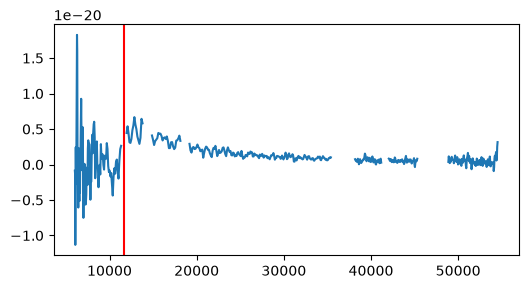

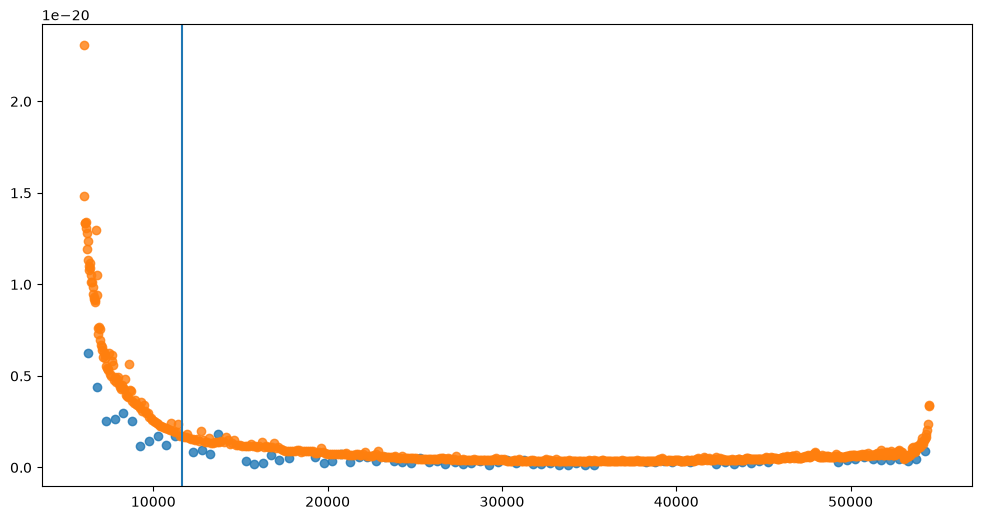

In [117]:

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# inputs
path = '/home/caltech-msanche3/data/new_spec_2/hlsp_jades_jwst_nirspec_goods-s-mediumjwst-165595_clear-prism_v1.0_x1d.fits'
z = 8.58
bin_size = 500

# data of spectrum
data = Table.read(path)
wavelengths = data['WAVELENGTH']*10000
flux = data['FLUX']

# Define emission line regions to mask [min_wave, max_wave]
#emission_lines = [(0,1216*(1+6.71)-1000),(28500, 30100),(33000,33800),(37178,38878),(50493,51593)]
emission_lines = [(1216*(1+z)-300,1216*(1+z)+300),(1450*(1+z),1550*(1+z)),(3700*(1+z), 3980*(1+z)),(1900*(1+z), 2000*(1+z)), (4300*(1+z),4383*(1+z)),(4730*(1+z),5100*(1+z)),(6439*(1+z),6691*(1+z))]

# Initialize a false mask (nothing masked)
mask1 = np.zeros_like(wavelengths, dtype=bool)

# Loop through and flag emission line intervals
for min_w, max_w in emission_lines:
    mask1 |= (wavelengths >= min_w) & (wavelengths <= max_w)

# Apply mask (masked points set to True)
masked_flux = np.ma.masked_array(flux, mask=mask1)

# plot masked spectrum
plt.figure(figsize=(6,3))
plt.plot(wavelengths,masked_flux)
plt.axvline(x=1216*(1+z),c='r')

# assign different names
wav = wavelengths
noisy_flux = masked_flux

# change wave and flux lists into numpy arrays
wav_val = np.asarray(wav.value if hasattr(wav, 'value') else wav)
noisy_flux_val = np.asarray(noisy_flux.value if hasattr(noisy_flux, 'value') else noisy_flux)

# initialize lists for Root Mean Square, the mean noisy flux in window, and the mean wavelength in window (should be center value)
rmss = []
mean_noisy_fluxes = []
mean_wave = []

# bin data
min_wav = np.min(wav_val)
max_wav = np.max(wav_val)

bin_edges = np.arange(min_wav, max_wav + bin_size, bin_size)
print(len(bin_edges)-1)
for i in range(len(bin_edges) - 1):
    low = bin_edges[i]
    high = bin_edges[i + 1]

    mask = (wav_val >= low) & (wav_val < high)

    # Require at least 2 points to compute difference between neighbors
    if np.sum(mask) < 2:
        continue

    # use mask for data binning
    wav_bin = wav_val[mask]
    noisy_flux_bin = noisy_flux_val[mask]

    mean_wave.append(np.mean(wav_bin))

    mean_noisy_flux = np.mean(noisy_flux_bin)
    mean_noisy_fluxes.append(mean_noisy_flux)
    
    # calcualte estimate of the noise (RMS)
    left = noisy_flux_bin[1:]
    right = noisy_flux_bin[:-1]
    diff = (left - right) ** 2
    rms = np.sqrt(np.mean(diff))
    rmss.append(rms)

# make lists into numpy arrays
rmss = np.array(rmss)
mean_wave = np.array(mean_wave)


# mask emission lines and LyAlpha forest location list
#emission_lines = [(0,1216*(1+z)-1000),(3700*(1+z), 3904*(1+z)),(4280*(1+z),4383*(1+z)),(4822*(1+z),5094*(1+z)),(6549*(1+z),6691*(1+z))]

mask1 = np.zeros_like(mean_wave, dtype=bool)

for min_w, max_w in emission_lines:
    mask1 |= (mean_wave >= min_w) & (mean_wave <= max_w)

masked_rmss = np.ma.masked_array(rmss, mask=mask1)
masked_wave = np.ma.masked_array(mean_wave,mask=mask1)

#plot estimated errors over reported errors
plt.figure(figsize=(12,6))
#plt.scatter(mean_wave,rmss,alpha=.8)
plt.scatter(masked_wave,masked_rmss,alpha=.8)
plt.scatter(wavelengths,data['FLUX_ERR'],alpha=.8)
#plt.ylim(0,.5e-20)
plt.axvline(x=1216*(1+z))
print(wav_val[0])
plt.show()

(0.0, 2.5e-21)

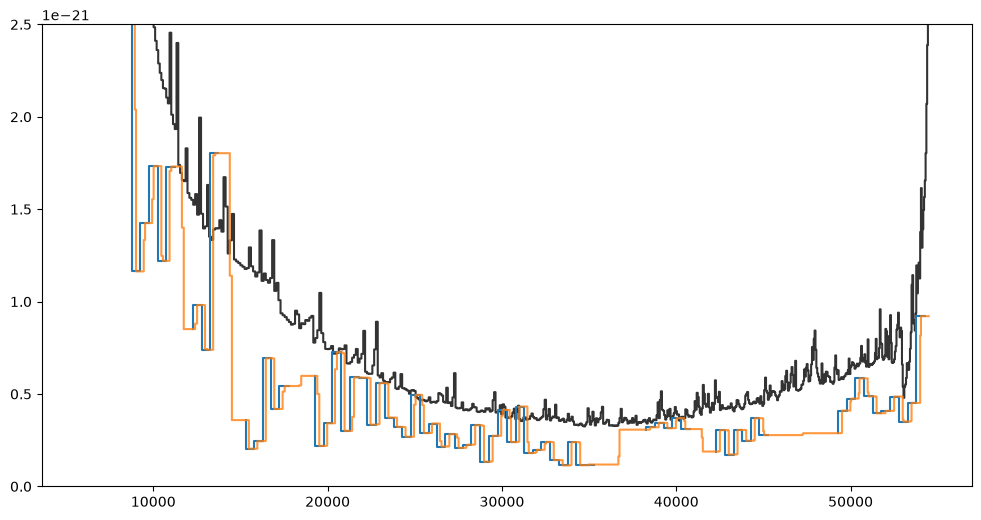

In [118]:
from spectres import spectres

# create arrays with no masked values for good interpolation
clean_masked_wave = [x for x in masked_wave if x != '--']
clean_masked_rmss = [x for x in masked_rmss if x != '--']

error_model_interp = spectres(
        wavelengths,              # Target wavelength
        np.array(clean_masked_wave),              # model wavelength grid
        np.array(clean_masked_rmss),              #  model RMS
        fill=np.nan,              # Fill value for out-of-bounds wavelengths
        verbose=False
    )

# plot estimates and interpolated estimates
plt.figure(figsize=(12,6))
plt.step(wavelengths,data['FLUX_ERR'],alpha=.8,c='k')
plt.step(masked_wave,masked_rmss,alpha=1)
plt.step(wavelengths,error_model_interp,alpha=.8)
plt.ylim(0,.25e-20)


706 706 706


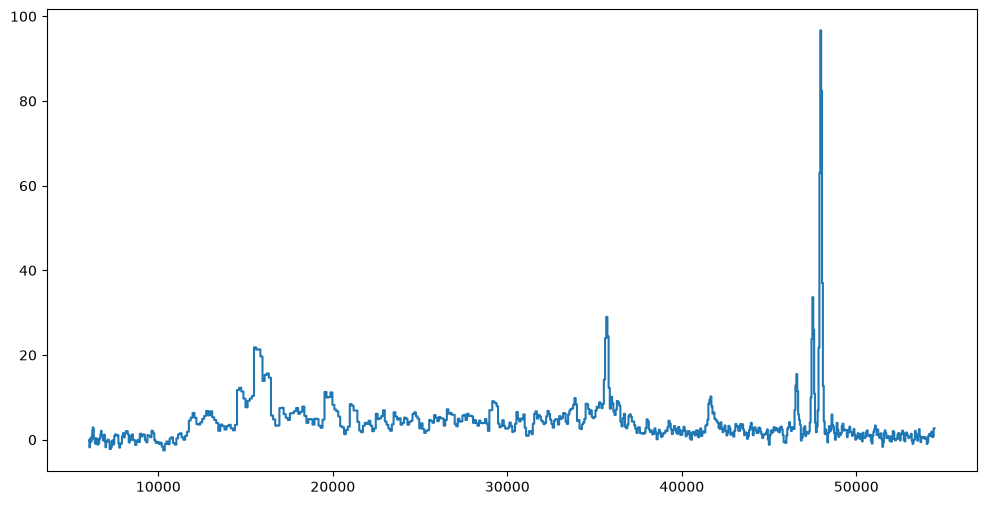

In [119]:
# save to custom fits file
wavelength = data['WAVELENGTH']
flux = data['FLUX']
flux_err = error_model_interp
print(len(wavelength),len(flux),len(flux_err))


# 2. Combine them into an Astropy Table
table = Table([wavelength, flux, flux_err], names=("WAVELENGTH", "FLUX", "FLUX_ERR erg s-1 cm-2 AA-1"))

# 3. View the table
#print(table)

# 4. Save the table
table.write('jades_goods_south_165595.fits', format='fits', overwrite=True)

# 5. Plot the table
plt.figure(figsize=(12,6))
plt.step(wavelengths,flux/flux_err)